# Wine 데이터
 https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

In [1]:
import urllib.request
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# 저장 경로 지정
save_path = "./winequality-red.csv"

urllib.request.urlretrieve(url, save_path)
print("다운로드 완료:", os.path.abspath(save_path))

다운로드 완료: /home/ubuntu/projects/winequality-red.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

I0000 00:00:1774590292.813481  180134 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774590292.925707  180134 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774590294.615991  180134 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
redwine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
redwine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
redwine.describe

<bound method NDFrame.describe of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.0

In [5]:
X, y = redwine.iloc[:,:-1], redwine.iloc[:, -1]

In [6]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [7]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [8]:
X.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [9]:
y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [10]:
y.head()

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

# y의 라벨인코딩 3~8 -> 0~5

In [11]:
from  sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
np.unique(y_encoded)

array([0, 1, 2, 3, 4, 5])

# 학습/테스트 데이터 분할

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
  X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [13]:
X_train.shape, X_test.shape

((1279, 11), (320, 11))

In [14]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [15]:
X_train_scaled_ary = np.array(X_train_scaled)
X_test_scaled_ary = np.array(X_test_scaled)

In [16]:
type(X_train_scaled_ary)

numpy.ndarray

In [17]:
from tensorflow.keras.utils import to_categorical

# y_train 원-핫 인코딩
y_train_ohe = to_categorical(y_train)
y_test_ohe  = to_categorical(y_test)

print("변환 전:", y_train.shape)       # (1199,)
print("변환 후:", y_train_ohe.shape)   # (1199, 6)

변환 전: (1279,)
변환 후: (1279, 6)


In [19]:
model.evaluate(X_test_scaled_ary, y_test_ohe)

NameError: name 'model' is not defined

# 한글폰트

In [20]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

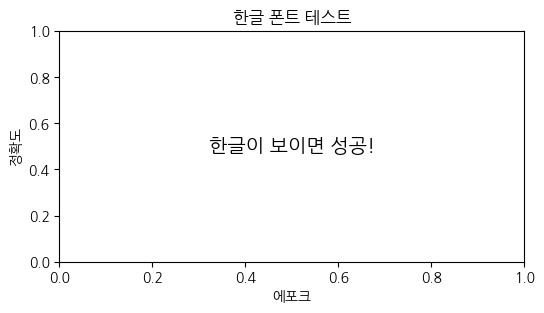

In [21]:
#한글 테스트
plt.figure(figsize=(6, 3))
plt.title('한글 폰트 테스트')
plt.xlabel('에포크')
plt.ylabel('정확도')
plt.text(0.5, 0.5, '한글이 보이면 성공!',
         ha='center', va='center', fontsize=14)
plt.show()

# 모델 생성

In [22]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

model.add(Input(shape=(11,))) #입력층

model.add(Dense(100, activation='sigmoid')) #은닉층1
model.add(Dropout(0.2))

model.add(Dense(200, activation='relu')) #은닉층2
model.add(Dropout(0.4))

model.add(Dense(50, activation='tanh')) #은닉층3
model.add(Dropout(0.1))

model.add(Dense(6, activation='softmax')) #출력층


I0000 00:00:1774590329.546736  180134 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [23]:
# 컴파일
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,756 (124.05 KB)

 Trainable params: 31,756 (124.05 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
          X_train_scaled_ary, y_train_ohe,   # ← y_train_ohe 로 변경
          epochs=300,
          batch_size=200,
          validation_split = 0.2,
          verbose=1
)

Epoch 1/300


I0000 00:00:1774590331.137819  180378 service.cc:153] XLA service 0x750478031ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774590331.137848  180378 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774590331.156570  180378 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774590331.272435  180378 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774590331.326695  180378 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1878__.21
I0000 00:00:1774590331.840979  180378 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

1/6 ━━━━━━━━━━━━━━━━━━━━ 20s 4s/step - accuracy: 0.1350 - loss: 2.1789

I0000 00:00:1774590334.471304  180378 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1774590334.641367  180380 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1878__.21
I0000 00:00:1774590334.966822  180380 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.2584 - loss: 1.9028

I0000 00:00:1774590338.381890  180380 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 957ms/step - accuracy: 0.3245 - loss: 1.7219 - val_accuracy: 0.4023 - val_loss: 1.3665
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4418 - loss: 1.2899 - val_accuracy: 0.4883 - val_loss: 1.3378
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4252 - loss: 1.2188 - val_accuracy: 0.4727 - val_loss: 1.2499
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4428 - loss: 1.2215 - val_accuracy: 0.5273 - val_loss: 1.2271
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4585 - loss: 1.1893 - val_accuracy: 0.4883 - val_loss: 1.2236
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4575 - loss: 1.1857 - val_accuracy: 0.4609 - val_loss: 1.2215
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4751 - loss: 1.1602 - val_accuracy: 0.5547 - val_loss: 1.1863
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4888 - loss: 1.1308 - val_accuracy: 0.5234 - val_loss: 1.1614
Epoc

In [25]:
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    verbose=1,
    validation_split=0.2   # 검증 데이터 20% 분리 (곡선에 필요)
)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6158 - loss: 0.8725 - val_accuracy: 0.5586 - val_loss: 1.1017
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6012 - loss: 0.8749 - val_accuracy: 0.5625 - val_loss: 1.1009
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6285 - loss: 0.8585 - val_accuracy: 0.5586 - val_loss: 1.1082
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6266 - loss: 0.8641 - val_accuracy: 0.5547 - val_loss: 1.1007
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6188 - loss: 0.8519 - val_accuracy: 0.5586 - val_loss: 1.0984
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6237 - loss: 0.8588 - val_accuracy: 0.5469 - val_loss: 1.1018
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6100 - loss: 0.8730 - val_accuracy: 0.5508 - val_loss: 1.0999
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6325 - loss: 0.8618 - val_accuracy: 0.5625 - val_loss:

# 원본 시각화

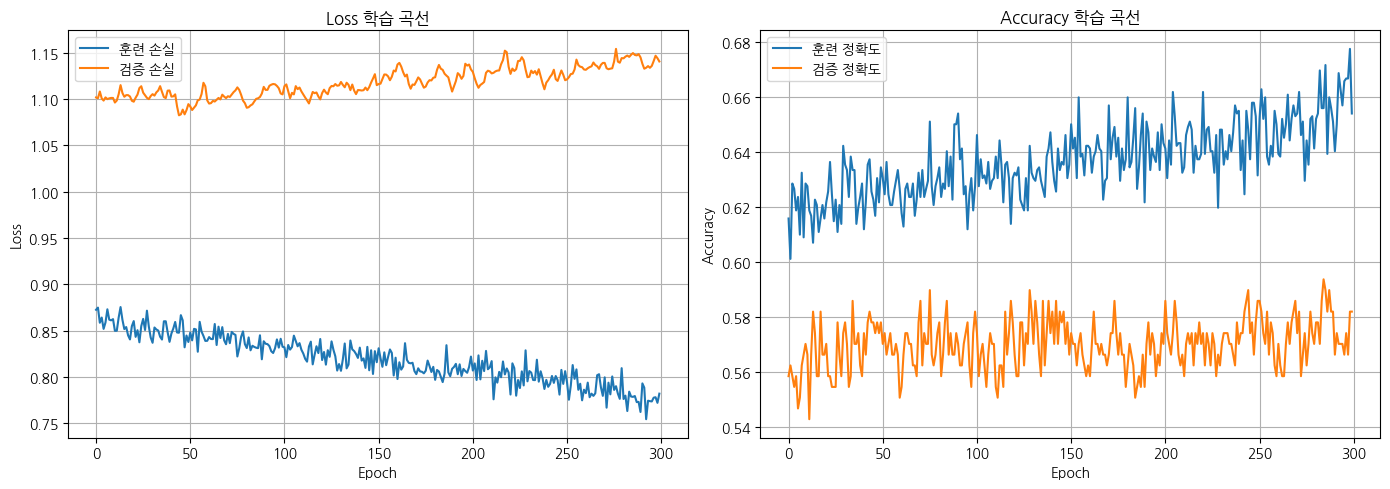

In [26]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 두번째 모델

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6549 - loss: 0.7654 - val_accuracy: 0.5742 - val_loss: 1.1392
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6588 - loss: 0.7675 - val_accuracy: 0.5664 - val_loss: 1.1439
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6579 - loss: 0.7587 - val_accuracy: 0.5742 - val_loss: 1.1469
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6628 - loss: 0.7726 - val_accuracy: 0.5547 - val_loss: 1.1503
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6364 - loss: 0.7860 - val_accuracy: 0.5742 - val_loss: 1.1538
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6422 - loss: 0.7830 - val_accuracy: 0.5703 - val_loss: 1.1536
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6383 - loss: 0.7894 - val_accuracy: 0.5664 - val_loss: 1.1547
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6657 - loss: 0.7656 - val_accuracy: 0.5625 - val_loss:

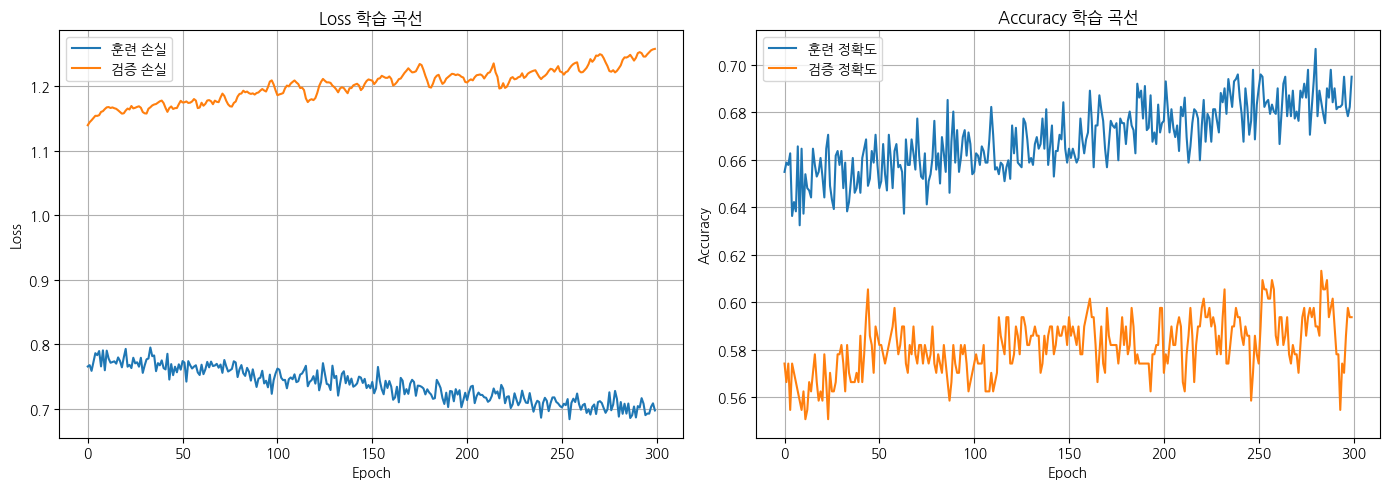

In [27]:
# 학습
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    verbose=1,
    validation_split=0.2
)

# 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 두번째 시각화

# 조기종료 적용 

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6891 - loss: 0.6908 - val_accuracy: 0.5977 - val_loss: 1.2599
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6989 - loss: 0.6841 - val_accuracy: 0.6016 - val_loss: 1.2611
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6852 - loss: 0.7003 - val_accuracy: 0.5820 - val_loss: 1.2594
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6931 - loss: 0.6821 - val_accuracy: 0.5742 - val_loss: 1.2588
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6696 - loss: 0.7197 - val_accuracy: 0.5938 - val_loss: 1.2541
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6833 - loss: 0.7101 - val_accuracy: 0.5938 - val_loss: 1.2550
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6921 - loss: 0.6856 - val_accuracy: 0.5938 - val_loss: 1.2559
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6784 - loss: 0.7086 - val_accuracy: 0.5977 - val_loss: 1.2603
Epoc

In [38]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Input(shape=(11,)))

model.add(Dense(256, activation='relu'))    # 64 → 256
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))    # 32 → 128
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))     # 은닉층 1개 추가
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(6, activation='softmax'))

# 컴파일
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# 학습
history = model.fit(
    X_train_scaled_ary, y_train_ohe,
    epochs=300,
    batch_size=200,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

model.summary()

Epoch 1/300


I0000 00:00:1774591372.757719  180378 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87016__.39
I0000 00:00:1774591373.019042  180378 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774591373.675174  180378 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774591373.955208  273855 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_26', 28 bytes spill stores, 28 bytes spill loads



1/6 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.1750 - loss: 2.6998

I0000 00:00:1774591377.001439  180381 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_87016__.39


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1633 - loss: 2.5810 

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,428 (536.83 KB)

 Trainable params: 45,510 (177.77 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 91,022 (355.56 KB)

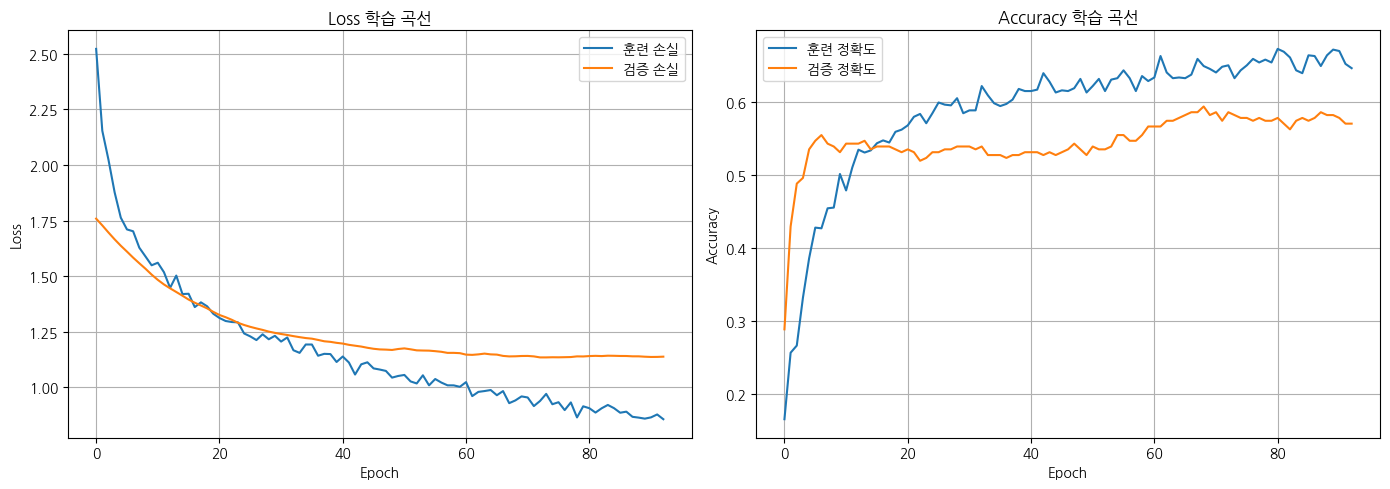

테스트 Loss    : 1.0204
테스트 Accuracy: 0.6094 (60.94%)


In [41]:
# 함수 정의
def plot_learning_curves(history):
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='훈련 손실')
    axes[0].plot(history.history['val_loss'], label='검증 손실')
    axes[0].set_title('Loss 학습 곡선')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
    axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
    axes[1].set_title('Accuracy 학습 곡선')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# 시각화 실행
plot_learning_curves(history)

# 테스트 평가
loss, acc = model.evaluate(X_test_scaled_ary, y_test_ohe, verbose=0)
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc:.4f} ({acc*100:.2f}%)")

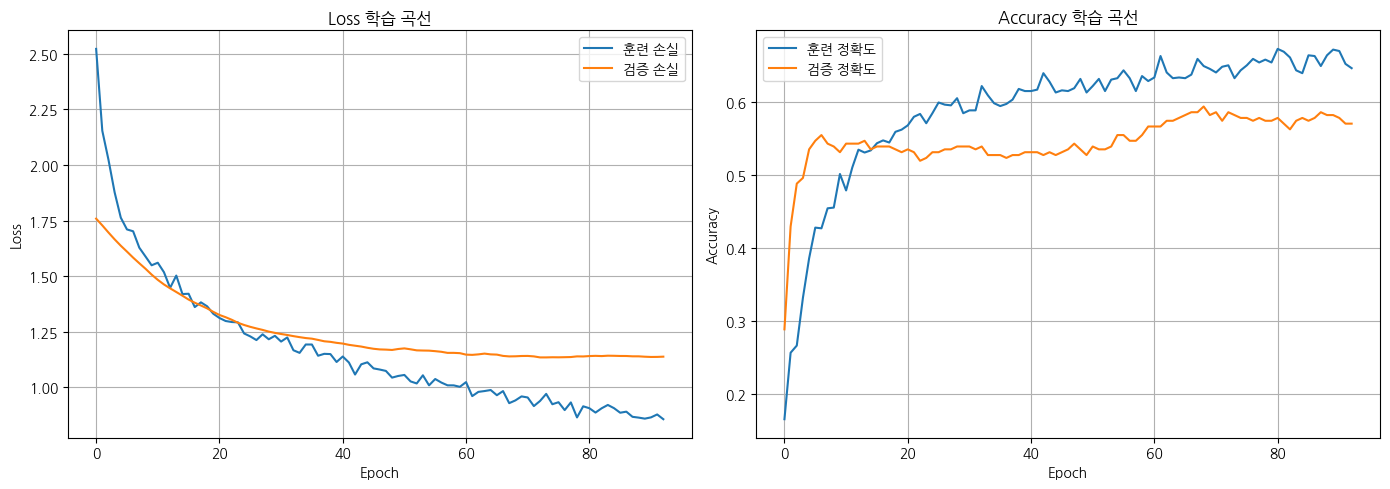

테스트 Loss    : 1.0204
테스트 Accuracy: 0.6094 (60.94%)


In [42]:
# 이 두 줄 실행 결과를 보여주세요
plot_learning_curves(history)

loss, acc = model.evaluate(X_test_scaled_ary, y_test_ohe, verbose=0)
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc:.4f} ({acc*100:.2f}%)")

In [30]:
import pandas as pd
print(pd.Series(y_train).value_counts().sort_index())

0      8
1     42
2    545
3    510
4    159
5     15
Name: count, dtype: int64


# 조기종료 시각화

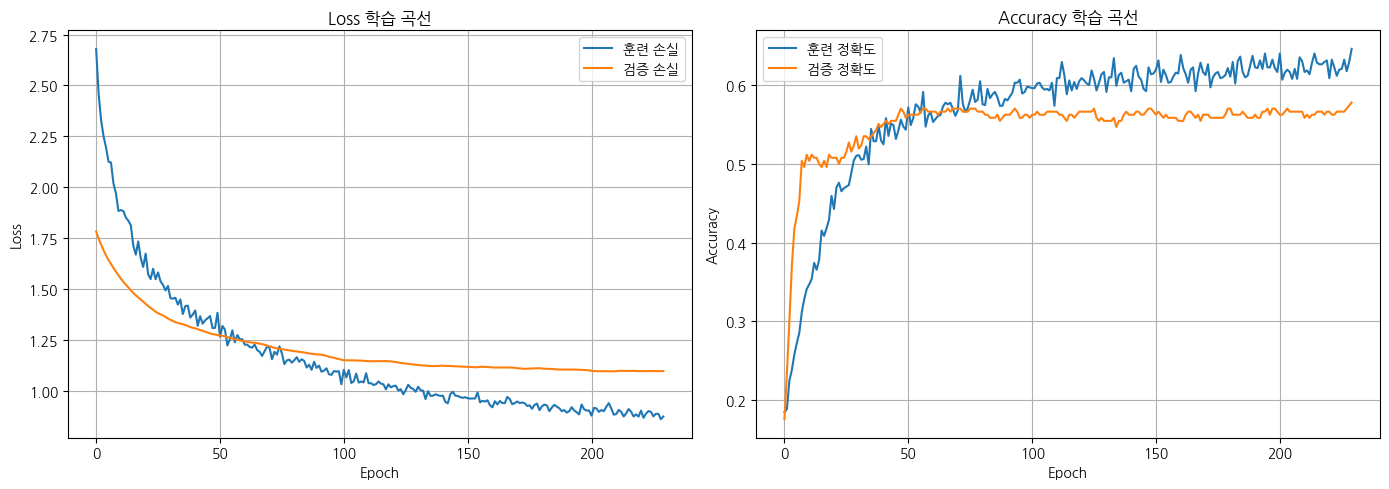

In [31]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 오른쪽: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 조기종료 적용 결과 검증

테스트 Loss    : 0.9412
테스트 Accuracy: 0.5938 (59.38%)
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

===== Classification Report =====
              precision    recall  f1-score   support

        품질 3       0.00      0.00      0.00         2
        품질 4       0.00      0.00      0.00        11
        품질 5       0.64      0.68      0.66       136
        품질 6       0.54      0.66      0.59       128
        품질 7       0.72      0.33      0.45        40
        품질 8       0.00      0.00      0.00         3

    accuracy                           0.59       320
   macro avg       0.32      0.28      0.28       320
weighted avg       0.58      0.59      0.57       320



/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

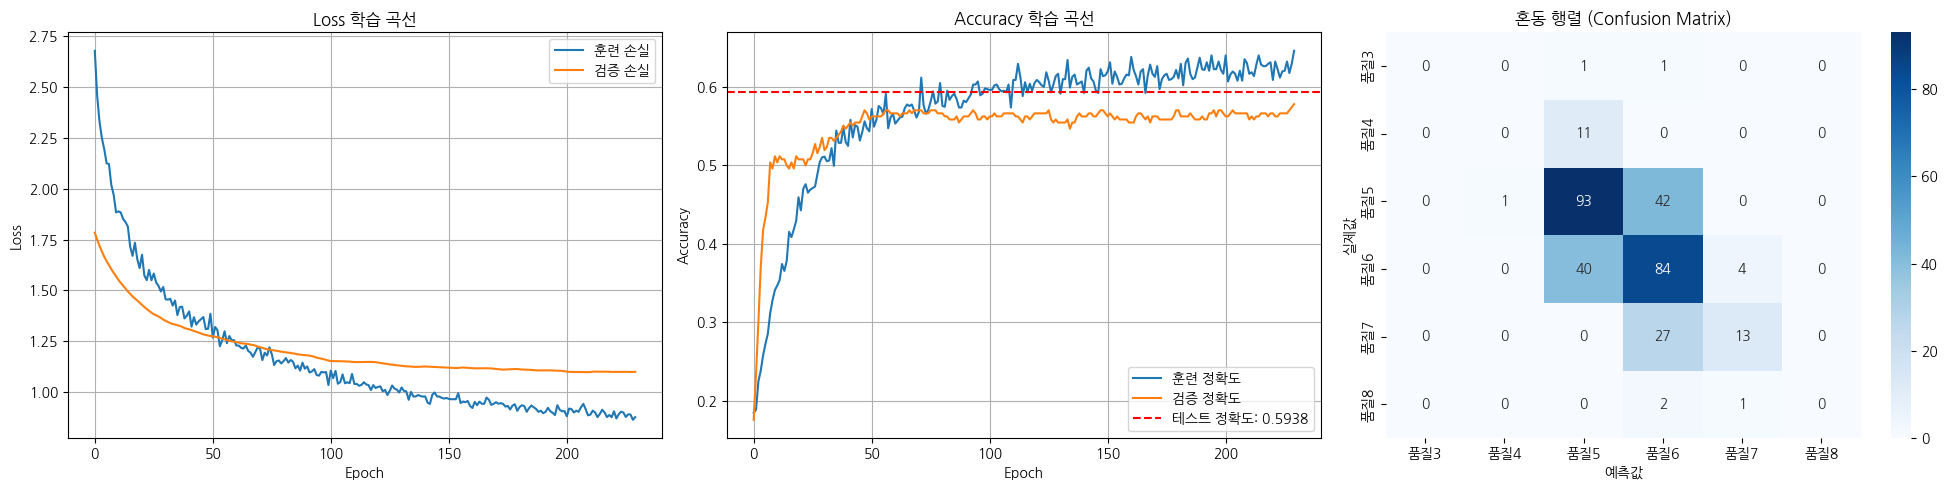


===== 결과 요약 DataFrame =====


/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ubuntu/miniforge3/envs/dl_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

,precision,recall,f1-score,support
품질 3,0.0000,0.0000,0.0000,2.0000
품질 4,0.0000,0.0000,0.0000,11.0000
품질 5,0.6414,0.6838,0.6619,136.0000
품질 6,0.5385,0.6562,0.5915,128.0000
품질 7,0.7222,0.3250,0.4483,40.0000
품질 8,0.0000,0.0000,0.0000,3.0000
accuracy,0.5938,0.5938,0.5938,0.5938
macro avg,0.3170,0.2775,0.2836,320.0000
weighted avg,0.5782,0.5938,0.5740,320.0000


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 1. 테스트 데이터 평가 ──
loss, acc = model.evaluate(X_test_scaled_ary, y_test_ohe, verbose=0)
print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ── 2. 예측값 생성 ──
y_pred_prob = model.predict(X_test_scaled_ary)   # 확률값 (None, 6)
y_pred      = np.argmax(y_pred_prob, axis=1)      # 예측 클래스
y_true      = np.argmax(y_test_ohe,  axis=1)      # 실제 클래스

# ── 3. Classification Report ──
print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred,
      target_names=[f'품질 {i+3}' for i in range(6)]))

# ── 4. 시각화 (3개 그래프) ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 그래프 1: Loss 곡선
axes[0].plot(history.history['loss'],     label='훈련 손실')
axes[0].plot(history.history['val_loss'], label='검증 손실')
axes[0].set_title('Loss 학습 곡선')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# 그래프 2: Accuracy 곡선
axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
axes[1].axhline(y=acc, color='red', linestyle='--', label=f'테스트 정확도: {acc:.4f}')
axes[1].set_title('Accuracy 학습 곡선')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# 그래프 3: 혼동 행렬 (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=[f'품질{i+3}' for i in range(6)],
            yticklabels=[f'품질{i+3}' for i in range(6)])
axes[2].set_title('혼동 행렬 (Confusion Matrix)')
axes[2].set_xlabel('예측값')
axes[2].set_ylabel('실제값')

plt.tight_layout()
plt.show()

# ── 5. 결과 요약 데이터프레임 ──
report_dict = classification_report(y_true, y_pred,
              target_names=[f'품질 {i+3}' for i in range(6)],
              output_dict=True)

df_report = pd.DataFrame(report_dict).T.round(4)
print("\n===== 결과 요약 DataFrame =====")
df_report

In [37]:
loss, acc = model.evaluate(X_test_scaled_ary, y_test_ohe, verbose=0)

print(f"테스트 Loss    : {loss:.4f}")
print(f"테스트 Accuracy: {acc:.4f}")
print(f"테스트 정확도  : {acc*100:.2f}%")

테스트 Loss    : 0.9412
테스트 Accuracy: 0.5938
테스트 정확도  : 59.38%


# model_es

In [33]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

model_es = Sequential()
model_es.add(Input(shape=(11,))) #입력층
model_es.add(Dense(100, activation='sigmoid')) #은닉층1
model_es.add(Dropout(0.2))
model_es.add(Dense(200, activation='relu')) #은닉층2
model_es.add(Dropout(0.4))
model_es.add(Dense(50, activation='tanh')) #은닉층3
model_es.add(Dropout(0.1))
model_es.add(Dense(6, activation='softmax')) #출력층

In [34]:
from tensorflow.keras.optimizers import Adam
model_es.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history1 = model_es.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774590452.320014  180380 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79580__.17


1/6 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.0850 - loss: 1.9467

I0000 00:00:1774590454.181251  180381 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79580__.17


6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 697ms/step - accuracy: 0.3050 - loss: 1.5625 - val_accuracy: 0.3867 - val_loss: 1.2789
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4350 - loss: 1.2271 - val_accuracy: 0.4023 - val_loss: 1.2884
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4526 - loss: 1.1810 - val_accuracy: 0.5000 - val_loss: 1.2365
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4604 - loss: 1.1744 - val_accuracy: 0.5469 - val_loss: 1.2202
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4594 - loss: 1.1737 - val_accuracy: 0.4961 - val_loss: 1.2181
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4936 - loss: 1.1345 - val_accuracy: 0.5039 - val_loss: 1.1940
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5132 - loss: 1.1111 - val_accuracy: 0.5352 - val_loss: 1.1600
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5112 - loss: 1.1060 - val_accuracy: 0.5508 - val_loss: 1.1471
Epo

In [36]:
plot_learning_curves(history1)

NameError: name 'plot_learning_curves' is not defined

# 활성화 함수 model build 함수

In [ ]:
def build_model(activation1='sigmoid', activation2='relu', activation3='tanh'):
    model = Sequential()

    model.add(Input(shape=(11,)))

    model.add(Dense(100, activation=activation1))  # 은닉층 1
    model.add(Dropout(0.2))

    model.add(Dense(200, activation=activation2))  # 은닉층 2
    model.add(Dropout(0.4))

    model.add(Dense(50, activation=activation3))   # 은닉층 3
    model.add(Dropout(0.1))

    model.add(Dense(6, activation='softmax'))       # 출력층

    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

# 활성화 함수 조합

In [ ]:
# 기본 조합 (원래 설정)
model = build_model(activation1='sigmoid', activation2='relu', activation3='tanh')

# 전부 relu
model = build_model(activation1='relu', activation2='relu', activation3='relu')

# 전부 tanh
model = build_model(activation1='tanh', activation2='tanh', activation3='tanh')

# 혼합 실험
model = build_model(activation1='relu', activation2='tanh', activation3='sigmoid')

# 여러 조합 한번에 비교

In [ ]:
combinations = [
    ('sigmoid', 'relu',    'tanh'),   # 원래 설정
    ('relu',    'relu',    'relu'),   # 전부 relu
    ('tanh',    'tanh',    'tanh'),   # 전부 tanh
    ('relu',    'tanh',    'relu'),   # 혼합
]

results = {}

for act1, act2, act3 in combinations:
    print(f"\n실험: {act1} / {act2} / {act3}")
    model = build_model(act1, act2, act3)
    history = model.fit(
        X_train_scaled_ary, y_train_ohe,
        epochs=50,
        batch_size=200,
        validation_split=0.2,
        verbose=0
    )
    val_acc = max(history.history['val_accuracy'])
    key = f"{act1}/{act2}/{act3}"
    results[key] = round(val_acc, 4)
    print(f"최고 검증 정확도: {val_acc:.4f}")

# 결과 비교
print("\n===== 실험 결과 비교 =====")
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{k:35s} → {v:.4f}")


실험: sigmoid / relu / tanh


I0000 00:00:1774579310.683666    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94125__.21
I0000 00:00:1774579312.548514    2433 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94125__.21


최고 검증 정확도: 0.5742

실험: relu / relu / relu


I0000 00:00:1774579321.508524    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99114__.21
I0000 00:00:1774579323.389061    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99114__.21
I0000 00:00:1774579325.630921    2432 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


최고 검증 정확도: 0.6016

실험: tanh / tanh / tanh


I0000 00:00:1774579331.911458    2431 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104103__.21
I0000 00:00:1774579333.776071    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_104103__.21


최고 검증 정확도: 0.5781

실험: relu / tanh / relu


I0000 00:00:1774579341.088269    2430 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109092__.21
I0000 00:00:1774579342.895887    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109092__.21


최고 검증 정확도: 0.5938

===== 실험 결과 비교 =====
relu/relu/relu                      → 0.6016
relu/tanh/relu                      → 0.5938
tanh/tanh/tanh                      → 0.5781
sigmoid/relu/tanh                   → 0.5742


# 활성화 함수 결과 비교 시각화

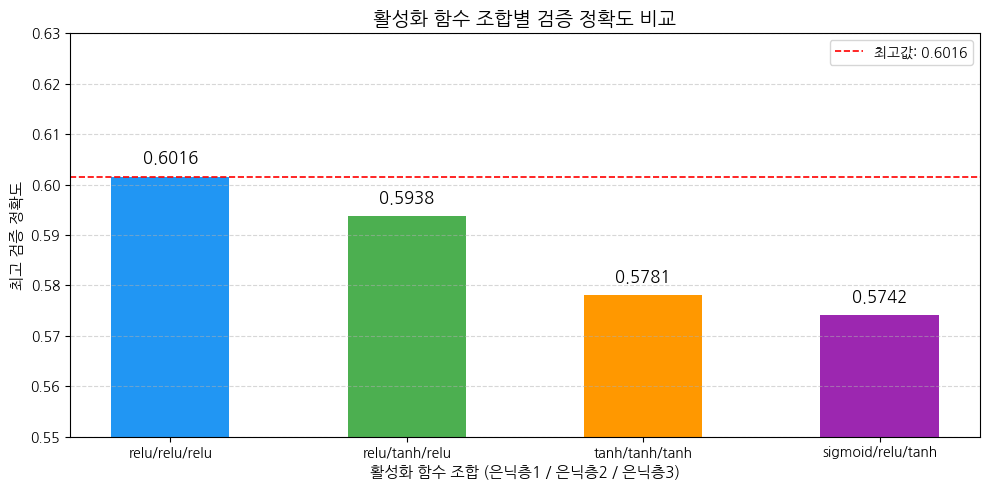

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 실험 결과
labels  = ['relu/relu/relu', 'relu/tanh/relu', 'tanh/tanh/tanh', 'sigmoid/relu/tanh']
scores  = [0.6016,            0.5938,            0.5781,            0.5742]
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(labels, scores, color=colors, width=0.5)

# 막대 위에 수치 표시
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{score:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# 최고값 강조선
ax.axhline(y=max(scores), color='red', linestyle='--', linewidth=1.2, label=f'최고값: {max(scores)}')

ax.set_title('활성화 함수 조합별 검증 정확도 비교', fontsize=14)
ax.set_xlabel('활성화 함수 조합 (은닉층1 / 은닉층2 / 은닉층3)', fontsize=11)
ax.set_ylabel('최고 검증 정확도', fontsize=11)
ax.set_ylim(0.55, 0.63)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 활성화 함수 결과

In [ ]:
import pandas as pd

df_results = pd.DataFrame({
    '순위':      [1, 2, 3, 4],
    '조합':      ['relu/relu/relu', 'relu/tanh/relu', 'tanh/tanh/tanh', 'sigmoid/relu/tanh'],
    '검증 정확도': ['60.16%', '59.38%', '57.81%', '57.42%'],
    '비고':      ['최고 성능', '근접한 성능', '보통', '최저 (원래 설정)']
})

df_results.set_index('순위', inplace=True)

df_results

,조합,검증 정확도,비고
순위,,,
1,relu/relu/relu,60.16%,최고 성능
2,relu/tanh/relu,59.38%,근접한 성능
3,tanh/tanh/tanh,57.81%,보통
4,sigmoid/relu/tanh,57.42%,최저 (원래 설정)


# batch normalization

In [ ]:
# 모델 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

model_br = Sequential()
model_br.add(Input(shape=(11,))) #입력층

model_br.add(Dense(100, activation='relu')) #은닉층1
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.2))

model_br.add(Dense(200, activation='relu')) #은닉층2
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.4))

model_br.add(Dense(50, activation='relu')) #은닉층3
model_br.add(BatchNormalization()) #배치정규화 계층
model_br.add(Dropout(0.1))

model_br.add(Dense(6, activation='softmax')) #출력층

from tensorflow.keras.optimizers import Adam
model_br.compile(
    #optimizer='adam',
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# batch 정규화 학습

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
#model.fit(..., callbacks=[early_stop])

history3 = model_br.fit(X_train_scaled_ary, y_train, epochs=300,
                    batch_size=200, 
                    validation_split = 0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/300


I0000 00:00:1774581696.530543    2432 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121664__.35


1/6 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.1800 - loss: 2.3315

I0000 00:00:1774581699.481925    2434 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_121664__.35


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.1928 - loss: 2.3745

I0000 00:00:1774581704.693410    2430 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1774581705.061319    2430 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.2082 - loss: 2.3292 - val_accuracy: 0.1836 - val_loss: 1.7897
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3539 - loss: 1.9307 - val_accuracy: 0.4023 - val_loss: 1.7114
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3978 - loss: 1.7233 - val_accuracy: 0.4531 - val_loss: 1.6500
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4585 - loss: 1.6615 - val_accuracy: 0.5039 - val_loss: 1.5944
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4761 - loss: 1.6008 - val_accuracy: 0.5000 - val_loss: 1.5438
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5239 - loss: 1.5259 - val_accuracy: 0.5156 - val_loss: 1.4980
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5249 - loss: 1.4662 - val_accuracy: 0.5352 - val_loss: 1.4611
Epoch 8/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5445 - loss: 1.4095 - val_accuracy: 0.5391 - val_loss: 1.4285
Epoch

In [ ]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

I0000 00:00:1774581847.027358    2431 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6156 - loss: 0.9883


In [ ]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6156 - loss: 0.9883 


In [ ]:
batch 정규화 시각화

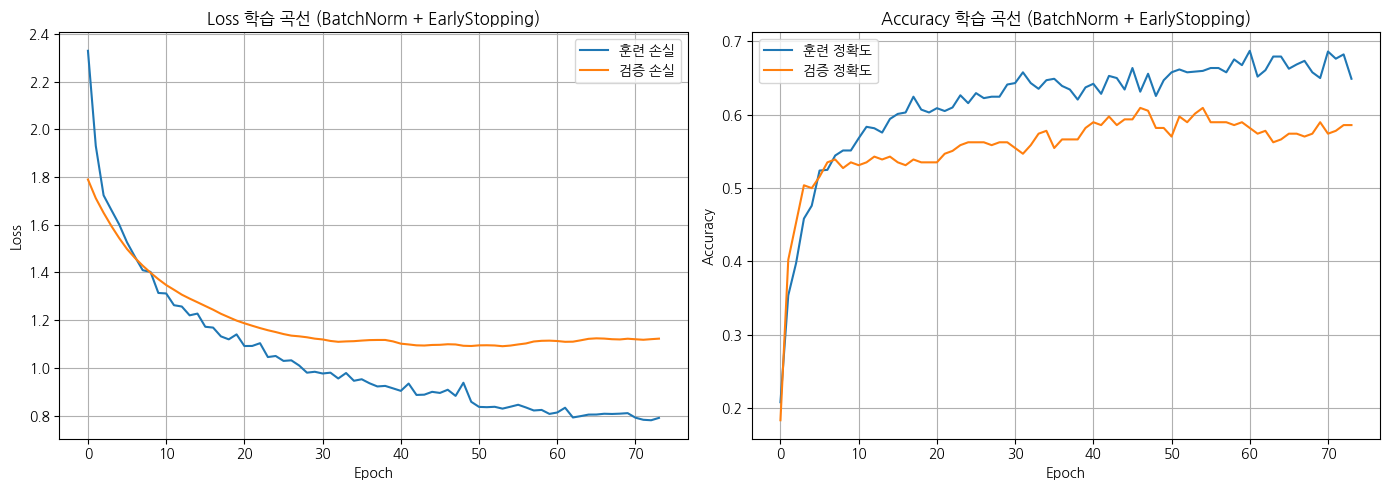

In [ ]:
def plot_learning_curves(history):
    import matplotlib.pyplot as plt
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 왼쪽: Loss 곡선
    axes[0].plot(history.history['loss'],     label='훈련 손실')
    axes[0].plot(history.history['val_loss'], label='검증 손실')
    axes[0].set_title('Loss 학습 곡선 (BatchNorm + EarlyStopping)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # 오른쪽: Accuracy 곡선
    axes[1].plot(history.history['accuracy'],     label='훈련 정확도')
    axes[1].plot(history.history['val_accuracy'], label='검증 정확도')
    axes[1].set_title('Accuracy 학습 곡선 (BatchNorm + EarlyStopping)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history3)

# batch 정규화 결과

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6156 - loss: 0.9883 


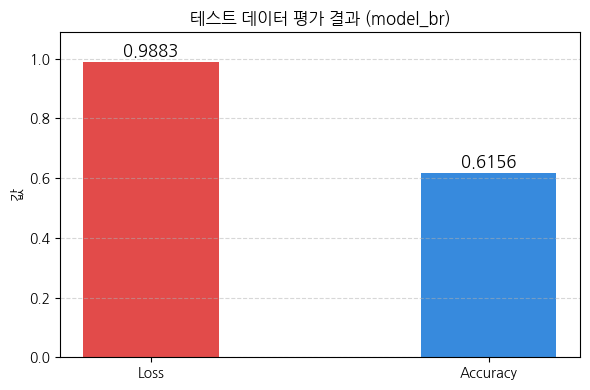

In [ ]:
loss, acc = model_br.evaluate(X_test_scaled_ary, y_test)

import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(['Loss', 'Accuracy'], [loss, acc], color=['#E24B4A', '#378ADD'], width=0.4)

for bar, val in zip(bars, [loss, acc]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('테스트 데이터 평가 결과 (model_br)')
ax.set_ylabel('값')
ax.set_ylim(0, max(loss, acc) + 0.1)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()